In [10]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap

# Φορτώνουμε embeddings και labels
models_path = os.path.expanduser("~/igbert-embedding-analysis/results/models/")
figures_path = os.path.expanduser("~/igbert-embedding-analysis/results/figures/")

# Φορτώνουμε ξανά τα νέα embeddings
embeddings_l30 = np.load(models_path + "embeddings_l30.npy")
embeddings_l15 = np.load(models_path + "embeddings_l15.npy")

print("Πρώτες 5 τιμές της πρώτης sequence (layer 15):")
print(embeddings_l15[0, :5])

print("\nΠρώτες 5 τιμές της δεύτερης sequence (layer 15):")
print(embeddings_l15[1, :5])

print(f"\nΜέση απόλυτη διαφορά seq1 vs seq2: {np.abs(embeddings_l15[0] - embeddings_l15[1]).mean():.8f}")
print(f"Variance layer 15: {embeddings_l15.var(axis=0).mean():.8f}")

Πρώτες 5 τιμές της πρώτης sequence (layer 15):
[ 0.00768799 -0.00780267  0.01349777  0.21002594  0.064229  ]

Πρώτες 5 τιμές της δεύτερης sequence (layer 15):
[ 0.01672188 -0.00223202 -0.04659929  0.16540758 -0.03832382]

Μέση απόλυτη διαφορά seq1 vs seq2: 0.03511878
Variance layer 15: 0.00111763


Explained variance από PC1 και PC2:
PC1: 36.0%
PC2: 13.3%
Σύνολο: 49.3%


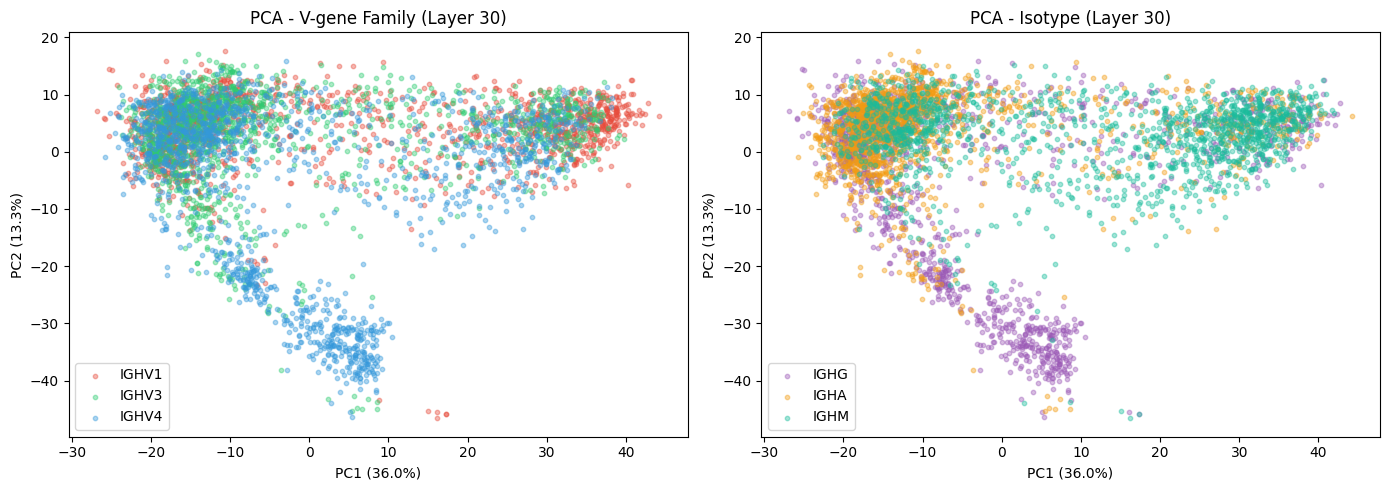

Αποθηκεύτηκε: pca_layer30.png


In [11]:
# Standardization: κανονικοποιούμε τα embeddings πριν το PCA
scaler = StandardScaler()
embeddings_l30_scaled = scaler.fit_transform(embeddings_l30)

# PCA: από 1024 διαστάσεις → 2 για visualization
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(embeddings_l30_scaled)

print(f"Explained variance από PC1 και PC2:")
print(f"PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Σύνολο: {sum(pca.explained_variance_ratio_)*100:.1f}%")

# Plot: χρωματισμός κατά V-gene family
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Αριστερά: κατά V-gene family
colors_vfamily = {'IGHV1': '#e74c3c', 'IGHV3': '#2ecc71', 'IGHV4': '#3498db'}
for family, color in colors_vfamily.items():
    mask = labels['v_family'] == family
    axes[0].scatter(pca_coords[mask, 0], pca_coords[mask, 1], 
                   c=color, label=family, alpha=0.4, s=10)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("PCA - V-gene Family (Layer 30)")
axes[0].legend()

# Δεξιά: κατά isotype
colors_isotype = {'IGHG': '#9b59b6', 'IGHA': '#f39c12', 'IGHM': '#1abc9c'}
for isotype, color in colors_isotype.items():
    mask = labels['isotype'] == isotype
    axes[1].scatter(pca_coords[mask, 0], pca_coords[mask, 1],
                   c=color, label=isotype, alpha=0.4, s=10)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("PCA - Isotype (Layer 30)")
axes[1].legend()

plt.tight_layout()
plt.savefig(figures_path + "pca_layer30.png", dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: pca_layer30.png")

Τρέχω UMAP (layer 30)...


/home/petrosk/miniconda3/envs/abinterp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


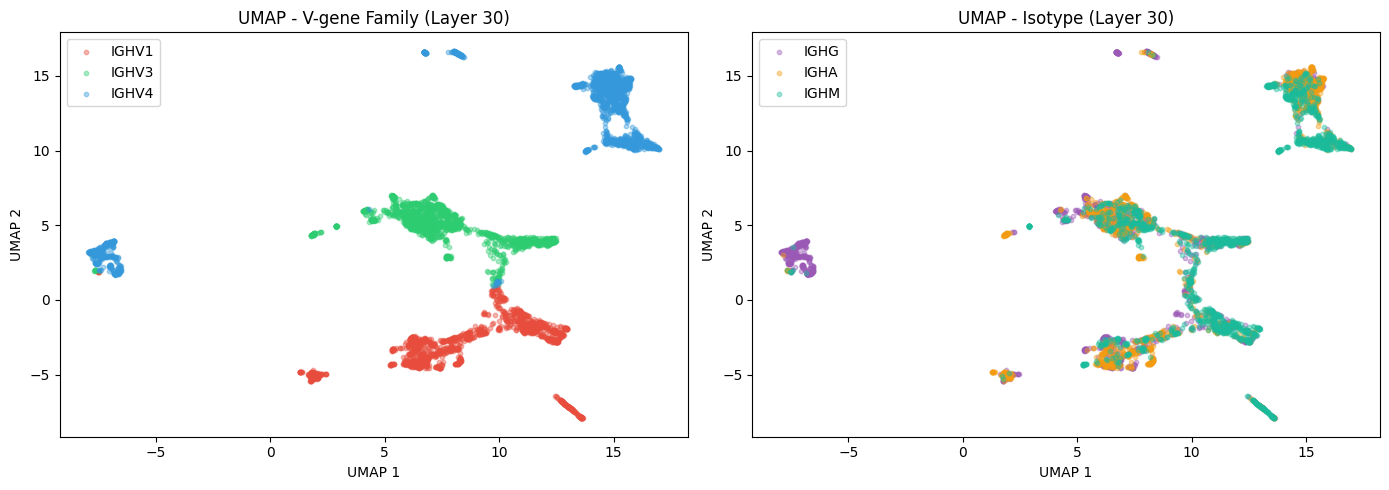

Αποθηκεύτηκε: umap_layer30.png


In [12]:
import umap

print("Τρέχω UMAP (layer 30)...")
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
umap_coords = reducer.fit_transform(embeddings_l30_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Αριστερά: V-gene family
for family, color in colors_vfamily.items():
    mask = labels['v_family'] == family
    axes[0].scatter(umap_coords[mask, 0], umap_coords[mask, 1],
                   c=color, label=family, alpha=0.4, s=10)
axes[0].set_title("UMAP - V-gene Family (Layer 30)")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
axes[0].legend()

# Δεξιά: Isotype
for isotype, color in colors_isotype.items():
    mask = labels['isotype'] == isotype
    axes[1].scatter(umap_coords[mask, 0], umap_coords[mask, 1],
                   c=color, label=isotype, alpha=0.4, s=10)
axes[1].set_title("UMAP - Isotype (Layer 30)")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].legend()

plt.tight_layout()
plt.savefig(figures_path + "umap_layer30.png", dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: umap_layer30.png")

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# KMeans με 3 clusters (ίσο με τον αριθμό των V-gene families)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings_l30_scaled)

# Πόσο καλά ταιριάζουν τα clusters με τα V-gene families;
v_family_numeric = pd.factorize(labels['v_family'])[0]
isotype_numeric = pd.factorize(labels['isotype'])[0]

ari_vfamily = adjusted_rand_score(v_family_numeric, cluster_labels)
ari_isotype = adjusted_rand_score(isotype_numeric, cluster_labels)

nmi_vfamily = normalized_mutual_info_score(v_family_numeric, cluster_labels)
nmi_isotype = normalized_mutual_info_score(isotype_numeric, cluster_labels)

print("Clustering vs V-gene family:")
print(f"  Adjusted Rand Index: {ari_vfamily:.3f}")
print(f"  Normalized Mutual Info: {nmi_vfamily:.3f}")

print("\nClustering vs Isotype:")
print(f"  Adjusted Rand Index: {ari_isotype:.3f}")
print(f"  Normalized Mutual Info: {nmi_isotype:.3f}")

print("\n(Τιμές κοντά στο 1.0 = τέλεια αντιστοιχία, 0 = τυχαία)")

Clustering vs V-gene family:
  Adjusted Rand Index: 0.038
  Normalized Mutual Info: 0.079

Clustering vs Isotype:
  Adjusted Rand Index: 0.109
  Normalized Mutual Info: 0.139

(Τιμές κοντά στο 1.0 = τέλεια αντιστοιχία, 0 = τυχαία)


In [14]:
# KMeans πάνω στις 2D UMAP συντεταγμένες
kmeans_umap = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels_umap = kmeans_umap.fit_predict(umap_coords)

ari_vfamily_umap = adjusted_rand_score(v_family_numeric, cluster_labels_umap)
nmi_vfamily_umap = normalized_mutual_info_score(v_family_numeric, cluster_labels_umap)

ari_isotype_umap = adjusted_rand_score(isotype_numeric, cluster_labels_umap)
nmi_isotype_umap = normalized_mutual_info_score(isotype_numeric, cluster_labels_umap)

print("KMeans on UMAP coords vs V-gene family:")
print(f"  Adjusted Rand Index: {ari_vfamily_umap:.3f}")
print(f"  Normalized Mutual Info: {nmi_vfamily_umap:.3f}")

print("\nKMeans on UMAP coords vs Isotype:")
print(f"  Adjusted Rand Index: {ari_isotype_umap:.3f}")
print(f"  Normalized Mutual Info: {nmi_isotype_umap:.3f}")

KMeans on UMAP coords vs V-gene family:
  Adjusted Rand Index: 0.475
  Normalized Mutual Info: 0.630

KMeans on UMAP coords vs Isotype:
  Adjusted Rand Index: 0.024
  Normalized Mutual Info: 0.088
